In [1]:
# Import libraries
from pathlib import Path 

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xarray as xr

import geopandas as gpd

In [2]:
# Input and output paths
ROOT      = Path().resolve().parent
RAW       = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed'
PROCESSED.mkdir(parents=True, exist_ok=True)

### Extracting Boundaries for Utrecht City and Utrecht Province



In [3]:
"""
    Download: https://service.pdok.nl/kadaster/brk-administratieve-eenheden/atom/downloads/administrativeunits.zip
    Unzip and place administrativeunits.gml in this folder (data/raw/)
"""

gdf = gpd.read_file(RAW / "administrativeunits.gml", layer="AdministrativeUnit")

print("New Columns:")
print(list(gdf.columns))

New Columns:
['gml_id', 'nationalCode', 'localId', 'namespace', 'LocalisedCharacterString', 'Country', 'language', 'sourceOfName', 'pronunciation', 'text', 'script', 'transliterationScheme', 'residenceOfAuthority|ResidenceOfAuthority|name|GeographicalName|language', 'residenceOfAuthority|ResidenceOfAuthority|name|GeographicalName|sourceOfName', 'residenceOfAuthority|ResidenceOfAuthority|name|GeographicalName|spelling|SpellingOfName|script', 'geometry', 'beginLifespanVersion', 'boundary', 'residenceOfAuthority|ResidenceOfAuthority|name|GeographicalName|spelling|SpellingOfName|text']


In [4]:
# Filter for entries containing "Utrecht"
utrecht_gdf = gdf[gdf['text'].str.contains("Utrecht", case=False, na=False)]

print("Found the following regions:")
print(utrecht_gdf[["gml_id", "text", "nationalCode"]])

Found the following regions:
                 gml_id                 text nationalCode
77   nl-imkad-au.GM0344              Utrecht         0344
108  nl-imkad-au.GM1581  Utrechtse Heuvelrug         1581
346    nl-imkad-au.PV26              Utrecht           26


In [5]:
utrecht_city = utrecht_gdf[utrecht_gdf["nationalCode"] == "0344"]
print(utrecht_city.crs)

utrecht_province = utrecht_gdf[utrecht_gdf['nationalCode'] == "26"]
print(utrecht_province.crs)

EPSG:4258
EPSG:4258


In [6]:
# Reproject to RD New (EPSG:28992)
utrecht_city = utrecht_city.to_crs(epsg=28992)
print(utrecht_city.crs)

utrecht_province = utrecht_province.to_crs(epsg=28992)
print(utrecht_province.crs)

EPSG:28992
EPSG:28992


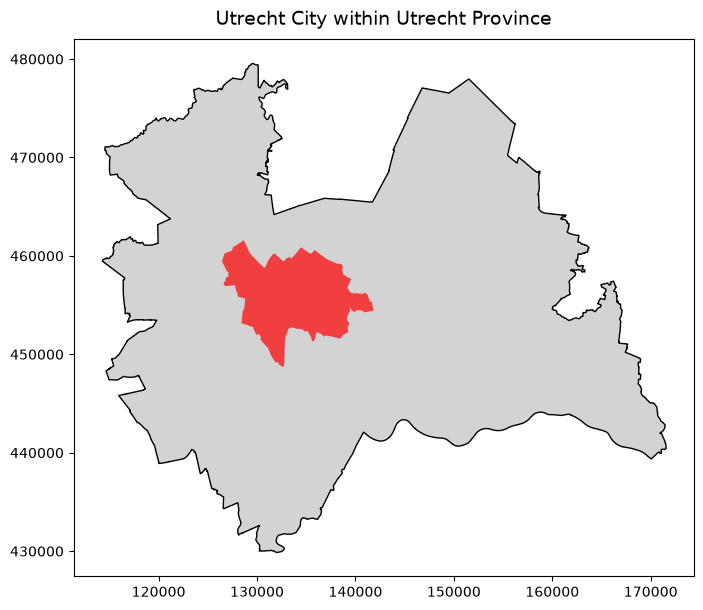

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))

utrecht_province.plot(ax=ax, color='lightgrey', edgecolor='black')
utrecht_city.plot(ax=ax, color='red', alpha=0.7)
ax.set_title("Utrecht City within Utrecht Province", fontsize=14, pad=10)

plt.show()

In [8]:
utrecht_city.to_file(PROCESSED / "utrecht_city.gpkg", driver="GPKG")
utrecht_province.to_file(PROCESSED / "utrecht_province.gpkg", driver="GPKG")

### Formation Coverage in Utrecht

In [9]:
"""
    - **Download:** https://www.thermogis.nl/sites/default/files/2026-05/for_external_use.zip)
    - Navigate to: `ThermoGIS_grids_2_5_1 > 6_Permian`
"""

'\n    - **Download:** https://www.thermogis.nl/sites/default/files/2026-05/for_external_use.zip)\n    - Navigate to: `ThermoGIS_grids_2_5_1 > 6_Permian`\n'

In [10]:
# Directory Paths
DATA_DIR = Path(r'C:\Users\sadar\Downloads\thermogis_data') 
GRID_DIR = DATA_DIR / 'ThermoGIS_grids_2_5_1' 
PERMIAN_GRID_DIR = GRID_DIR / '6_Permian'

# Utrecht Province Clip
X_MIN, X_MAX = 110_000, 180_000 
Y_MIN, Y_MAX = 420_000, 490_000

In [11]:
all_permian = list(PERMIAN_GRID_DIR.rglob("*.nc"))
print(f"Total Permian .nc fies: {len(all_permian)}")

rock_units = sorted(set(f.relative_to(PERMIAN_GRID_DIR).parts[0] for f in all_permian))
print(f"\nLithostratigraphic Units in 6_Permian folder:")
for unit in rock_units:
    print(f"  {unit}")

Total Permian .nc fies: 132

Lithostratigraphic Units in 6_Permian folder:
  Lower Slochteren Mb (ROSLL)
  Slochteren Fm & Upper Slochteren Mb (ROSL&ROSLU)
  Upper Rotliegend Gp (RO)


In [12]:
slochteren_fm = [unit for unit in rock_units if unit != "Upper Rotliegend Gp (RO)"] 

for mb in slochteren_fm:
    print(f"  {mb}")

  Lower Slochteren Mb (ROSLL)
  Slochteren Fm & Upper Slochteren Mb (ROSL&ROSLU)


In [13]:
for mb in slochteren_fm:
    # Find .nc files for members in Slochteren Formation
    sample_files = [
        f for f in all_permian
        if f.parts[-3] == mb
        and f.parent.name == 'BaseCase'
    ]
    if not sample_files:
        print(f"  {mb:55s} - no BaseCase files")
        continue

    # Extract Easting and Northing coordinates    
    f = sample_files[0]
    ds = xr.open_dataset(f)
    coords = list(ds.coords)
    x_coord = next((c for c in coords if c.lower() in ("x", "xrdr", "easting")), None)
    y_coord = next((c for c in coords if c.lower() in ("y", "rdy", "northing")), None)

    if not x_coord or not y_coord:
        print(f"  {mb:55s} - unrecognized coords:  {coords}")

    x_vals = ds[x_coord].values
    y_vals = ds[y_coord].values

    # Check overlap with Utrecht
    x_overlap = (x_vals.max() >= X_MIN) and (x_vals.min() <= X_MAX)
    y_overlap = (y_vals.max() >= Y_MIN) and (y_vals.min() <= Y_MAX)

    if x_overlap and y_overlap:
        # Check non-nulls
        ds_ut = ds.sel({
            x_coord: (x_vals >= X_MIN) & (x_vals <= X_MAX),
            y_coord: (y_vals >= Y_MIN) & (y_vals <= Y_MAX)
        })
        data = ds_ut['data'].values.flatten()
        n_valid = int(np.sum(~np.isnan(data) & (data > 0)))

        status = f"✓ PRESENT - {n_valid} valid cells in Utrecht"
    else:
        status = (f"x outside Utrecht   "
                  f"(x: {x_vals.min():.0f}-{x_vals.max():.0f}), "
                  f"y: {y_vals.min():.0f}-{y_vals.max():.0f})")
    print(f"    {mb:55s} - {status}")

    Lower Slochteren Mb (ROSLL)                             - x outside Utrecht   (x: 119000-262000), y: 574000-624000)
    Slochteren Fm & Upper Slochteren Mb (ROSL&ROSLU)        - ✓ PRESENT - 4405 valid cells in Utrecht


In [14]:
BASECASE_DIR = PERMIAN_GRID_DIR / "Slochteren Fm & Upper Slochteren Mb (ROSL&ROSLU)" / "BaseCase"

slochteren_fm_basecase = [
    f for f in BASECASE_DIR.rglob('*.nc')
    if f.name.upper().startswith("ROSL_ROSLU_")
]

for f in slochteren_fm_basecase:
    print(f"Processing and saving {f.name}...")
    ds = xr.open_dataset(f)
    ds.to_netcdf(RAW / f.name)
    ds.close()

Processing and saving ROSL_ROSLU_depth.nc...
Processing and saving ROSL_ROSLU_economic_potential.nc...
Processing and saving ROSL_ROSLU_flow_rate_p50.nc...
Processing and saving ROSL_ROSLU_heat_in_place.nc...


Processing and saving ROSL_ROSLU_net_to_gross.nc...
Processing and saving ROSL_ROSLU_permeability_p50.nc...
Processing and saving ROSL_ROSLU_porosity.nc...
Processing and saving ROSL_ROSLU_potential_recoverable_heat.nc...
Processing and saving ROSL_ROSLU_power_p50.nc...
Processing and saving ROSL_ROSLU_temperature.nc...
Processing and saving ROSL_ROSLU_thickness_p50.nc...
